# TP 2 : agrandir la base, puis la réduire

Le même modèle linéaire, mais nourri d'autres colonnes : d'abord beaucoup plus, ensuite beaucoup
moins.

## 2.0 Projeter les entrées dans un espace plus grand

Une droite ne peut pas suivre une tendance courbe. On n'abandonne pas le modèle linéaire pour
autant : on remplace $x$ par une **base de fonctions** $\phi(x)$, fixée avant l'ajustement, et on
ajuste linéairement dans cet espace plus grand :

$$h_w(x) = w^T \phi(x) = \sum_{j=0}^{M-1} w_j \phi_j(x), \qquad \phi_0(x) = 1 .$$

Avec $\phi(x) = (1, x)$ on retrouve exactement le modèle de tout à l'heure. Avec tous les monômes
jusqu'au degré $d$ ($x_1$, $x_1 x_2$, $x_3^2$, …), on obtient la **régression polynomiale**.

On empile les $\phi(x^{(i)})^T$ en lignes de $\Phi \in \mathbb{R}^{m \times M}$, et **rien ne
change** dans l'ajustement : $w = (\Phi^T \Phi)^{-1}\Phi^T y$, $w = (\Phi^T \Phi + \lambda
I)^{-1}\Phi^T y$.

Les colonnes de $\Phi$ n'ont plus la même échelle, un produit de trois mesures est bien plus
petit qu'une mesure seule, donc on les centre et on les réduit avant d'ajuster. Sinon la
pénalité $\lambda$ frapperait des colonnes incomparables.

**Q1.** La base de degré 2 compte 66 colonnes et celle de degré 3 en compte 286, pour 353 patients
d'entraînement. Avec 286 coefficients pour 353 points, le modèle peut coller de très près à chacun de
ses points d'entraînement. Qu'en concluez-vous sur ce que mesure son erreur d'entraînement ?

**Réponse attendue :** Avec 286 coefficients pour 353 patients, le modèle a presque autant de paramètres que de points à
ajuster : il peut passer très près de chacun d'eux, y compris de la part de chaque mesure qui n'est
que du bruit. Son erreur d'entraînement ne mesure donc plus la qualité de ce qu'il a appris, mais sa
capacité à reproduire les 353 patients qu'on lui a montrés. Elle sera petite parce que le modèle est
gros, pas parce qu'il a compris quelque chose.

Attention, une erreur d'entraînement basse n'est pas une bonne nouvelle ici, c'est plutôt l'inverse
: plus la base grandit, moins ce chiffre est informatif, et la seule information qui reste vient de
patients que le modèle n'a pas vus.

*Pour aller plus loin :* le nombre de colonnes vaut $M = \binom{n+d}{d}$, d'où 66 au degré 2 et 286
au degré 3 pour dix mesures. À $M = 353$ il existe en général une solution d'erreur d'entraînement
exactement nulle, et au-delà il y en a une infinité : $\Phi^T \Phi$ n'est plus inversible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

data = load_diabetes(as_frame=True)
feature_names = list(data.data.columns)
X, y = data.data.values, data.target.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


def design_matrix(Phi):
    """Add the dummy column phi_0 = 1 in front of a basis."""
    return np.hstack([np.ones((len(Phi), 1)), Phi])


def predict(Phi, w):
    return design_matrix(Phi) @ w


def polynomial_basis(degree, X_reference):
    """Monomials up to `degree`, centred and scaled on X_reference. Returns the function phi."""
    expand = PolynomialFeatures(degree, include_bias=False).fit(X_reference)
    scale = StandardScaler().fit(expand.transform(X_reference))
    return lambda A: scale.transform(expand.transform(A))


phi_2 = polynomial_basis(2, X_train)
assert phi_2(X_train).shape == (353, 65)
assert np.allclose(phi_2(X_train).mean(axis=0), 0.0)
assert np.allclose(phi_2(X_train).std(axis=0), 1.0)
assert not np.allclose(phi_2(X_test).mean(axis=0), 0.0)

for degree in (1, 2, 3):
    phi = polynomial_basis(degree, X_train)
    print(f"degré {degree} : M = {phi(X_train).shape[1] + 1} colonnes pour "
          f"{len(X_train)} patients")

degré 1 : M = 11 colonnes pour 353 patients
degré 2 : M = 66 colonnes pour 353 patients
degré 3 : M = 286 colonnes pour 353 patients


## 2.1 Ce que fait une base trop grande

**Q2.** La base de degré 2 contient celle de degré 1. Quand on passe du degré 1 au degré 2, le
$R^2$ d'entraînement peut-il descendre, ou ne peut-il que monter ? Qu'en concluez-vous sur la
possibilité de choisir $M$ avec ce chiffre ?

**Réponse attendue :** Il ne peut que monter. La base de degré 2 contient celle de degré 1 : tout ajustement atteignable
avec les 11 colonnes de la droite reste atteignable avec les 66, il suffit de laisser à zéro les
coefficients des colonnes ajoutées. Les moindres carrés cherchant le minimum de l'erreur sur un
ensemble de possibilités plus grand, le grand modèle fait au moins aussi bien que le petit. La
sortie suivante le confirme : 0,554 puis 0,632 puis 0,887.

Conséquence : ce chiffre ne peut pas servir à choisir $M$. Il classe toujours la plus grande base en
tête, donc l'optimiser revient à répondre « prenez le plus grand $M$ possible », sans jamais
prévenir que le modèle est devenu mauvais. Pour choisir, il faut un chiffre que le modèle ne peut
pas faire monter en ajoutant des colonnes : un score sur des patients qu'il n'a pas vus.

Attention, « ça dépend des données » ne convient pas : la monotonie ne dépend pas du jeu de données,
elle vient de l'emboîtement des deux bases.

In [2]:
def least_squares(Phi, y):
    """w = (Phi^T Phi)^-1 Phi^T y, via lstsq: at degree 3 the matrix is close to singular."""
    return np.linalg.lstsq(design_matrix(Phi), y, rcond=None)[0]


def r2(y, y_hat):
    return 1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2)


def rmse(y, y_hat):
    return np.sqrt(np.mean((y - y_hat) ** 2))


rows = []
for degree in (1, 2, 3):
    phi = polynomial_basis(degree, X_train)
    Phi_train, Phi_test = phi(X_train), phi(X_test)
    w = least_squares(Phi_train, y_train)
    rows.append({
        "M": Phi_train.shape[1] + 1,
        "cond(ΦᵀΦ)": np.linalg.cond(design_matrix(Phi_train).T @ design_matrix(Phi_train)),
        "R² entraînement": r2(y_train, predict(Phi_train, w)),
        "R² test": r2(y_test, predict(Phi_test, w)),
        "RMSE test": rmse(y_test, predict(Phi_test, w)),
    })

table = pd.DataFrame(rows, index=["degré 1", "degré 2", "degré 3"])
assert np.isclose(table.loc["degré 1", "R² test"],
                  LinearRegression().fit(X_train, y_train).score(X_test, y_test))
print(table.to_string(formatters={"cond(ΦᵀΦ)": "{:.2e}".format, "R² entraînement": "{:.3f}".format,
                                  "R² test": "{:.3f}".format, "RMSE test": "{:.1f}".format}))
print(f"\nRMSE de test du modèle qui prédit toujours la moyenne d'entraînement : "
      f"{rmse(y_test, np.full(len(y_test), y_train.mean())):.1f}")

           M cond(ΦᵀΦ) R² entraînement R² test RMSE test
degré 1   11  4.42e+02           0.554   0.332      58.5
degré 2   66  4.67e+16           0.632   0.291      60.3
degré 3  286  5.08e+17           0.887  -5.627     184.3

RMSE de test du modèle qui prédit toujours la moyenne d'entraînement : 71.7


**Q3.** Dans le tableau, le degré 3 affiche le meilleur $R^2$ d'entraînement, 0,887, et un RMSE de
test de 184,3 ; la ligne en dessous donne 71,7 pour le modèle qui répond toujours la moyenne. Le
degré 3 prédit-il mieux ou moins bien que ce modèle constant ? Qu'en concluez-vous sur son 0,887 ?

**Réponse attendue :** Moins bien, et de loin. Le degré 3 affiche 184,3 de RMSE de test, contre 71,7 pour le modèle qui
répond toujours la moyenne d'entraînement : il est environ deux fois et demie pire que de ne rien
apprendre du tout. Son $R^2$ de test, $-5{,}627$, dit la même chose autrement : un $R^2$ négatif
signifie « pire que de prédire la moyenne ».

Donc son 0,887 ne dit rien sur la qualité du modèle. C'est un score calculé sur les 353 patients qui
ont servi à l'ajuster : il mesure ce que le modèle a retenu, pas ce qu'il a compris. Les deux
colonnes de $R^2$ du tableau portent presque le même nom et ne répondent pas à la même question ;
ici elles classent les trois modèles dans l'ordre inverse.

Attention, la colonne d'entraînement se lit facilement comme une progression, 0,554 puis 0,632 puis
0,887, d'où la conclusion tentante que le degré 3 serait le meilleur des trois. C'est exactement le
raisonnement écarté en Q2, sur un cas où il coûte cher.

*Pour aller plus loin :* la colonne `cond(ΦᵀΦ)` vaut $5{,}08 \times 10^{17}$ au degré 3. Un nombre
flottant ne porte qu'une quinzaine de chiffres justes, donc à cette échelle la solution rendue n'est
plus « la » solution du système mais une solution parmi beaucoup d'autres, désignée par les
arrondis : les 286 monômes sont très redondants sur 353 points, et les coefficients rendus sont
énormes et arbitraires.

## 2.2 Le $+\lambda I$ rattrape la base

**Q4.** Le degré 3 a 286 colonnes pour 353 patients, et la droite obtient 0,332 de $R^2$ de test
dans le tableau ci-dessus. En ajoutant $\lambda I$, jusqu'où le $R^2$ de test du degré 3 peut-il
remonter : en dessous de 0,332, à peu près à 0,332, ou nettement au-dessus ?

**Réponse attendue :** À peu près au niveau de la droite, peut-être un peu au-dessus ; pas nettement au-dessus. La pénalité
ne fait qu'une chose : elle empêche les 286 coefficients de prendre de grandes valeurs. Elle peut
donc supprimer les valeurs arbitraires qui produisent le $-5{,}627$, mais elle n'apporte aucune
information nouvelle sur les patients. Si la relation est essentiellement linéaire, le mieux qu'elle
puisse faire est de ramener le degré 3 au comportement du degré 1, soit environ 0,332.

Deux réponses symétriques sont tentantes et fausses. « Nettement au-dessus », parce que 286 colonnes
bien réglées devraient battre 11 : cela oublie que la pénalité ne crée pas de signal. « En dessous
de 0,332 », parce que pénaliser ne peut que dégrader : cela oublie que le degré 3 non pénalisé est
catastrophique, donc qu'il y a énormément à récupérer avant de perdre quoi que ce soit. Toute
prédiction argumentée convient ici : c'est le raisonnement qui compte, pas le chiffre.

*Pour aller plus loin :* ce n'est pas parce qu'il existe un $\lambda$ qui amène le degré 3 à ce
niveau qu'on saura le trouver sans regarder le test. C'est ce que la section 2.3 met à l'épreuve.

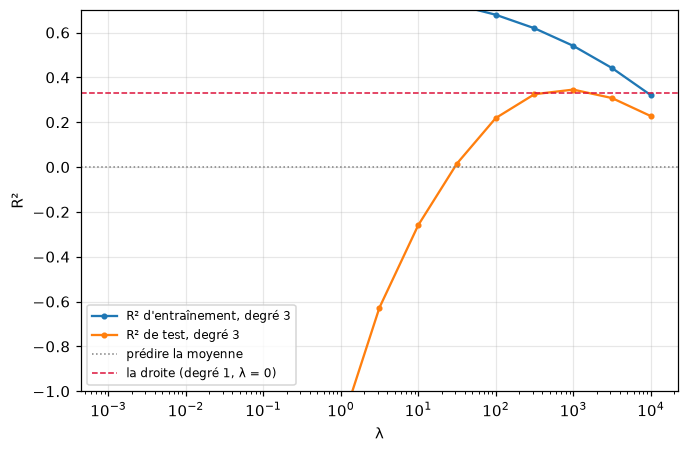

meilleur R² de test du degré 3 : 0.345 à λ = 1e+03


In [3]:
def ridge_equation(Phi, y, lam):
    """w = (Phi^T Phi + lam I)^-1 Phi^T y. The bias is not penalised."""
    A = design_matrix(Phi)
    penalty = lam * np.eye(A.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(A.T @ A + penalty, A.T @ y)


reference = Ridge(alpha=1.0).fit(phi_2(X_train), y_train)
assert np.isclose(ridge_equation(phi_2(X_train), y_train, 1.0)[0], reference.intercept_)
assert np.allclose(ridge_equation(phi_2(X_train), y_train, 1.0)[1:], reference.coef_)

lambdas = np.logspace(-3, 4, 15)
phi3 = polynomial_basis(3, X_train)
Phi3_train, Phi3_test = phi3(X_train), phi3(X_test)

r2_train_path, r2_test_path = [], []
for lam in lambdas:
    w_lam = ridge_equation(Phi3_train, y_train, lam)
    r2_train_path.append(r2(y_train, predict(Phi3_train, w_lam)))
    r2_test_path.append(r2(y_test, predict(Phi3_test, w_lam)))

assert len(r2_test_path) == 15
assert np.isclose(r2_test_path[0], r2(y_test, predict(Phi3_test, ridge_equation(Phi3_train, y_train, lambdas[0]))))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lambdas, r2_train_path, "o-", ms=3, label="R² d'entraînement, degré 3")
ax.plot(lambdas, r2_test_path, "o-", ms=3, label="R² de test, degré 3")
ax.axhline(r2(y_test, np.full(len(y_test), y_train.mean())),
           color="gray", ls=":", lw=1, label="prédire la moyenne")
ax.axhline(0.332, color="crimson", ls="--", lw=1, label="la droite (degré 1, λ = 0)")
ax.set_xscale("log")
ax.set_ylim(-1, 0.7)
ax.set_xlabel("λ")
ax.set_ylabel("R²")
ax.legend(fontsize=8)
plt.show()

best = int(np.argmax(r2_test_path))
print(f"meilleur R² de test du degré 3 : {r2_test_path[best]:.3f} à λ = {lambdas[best]:.3g}")

**Q5.** Le meilleur $R^2$ de test du degré 3 pénalisé est 0,345, et le trait rouge de la figure,
la droite, est à 0,332. Le degré 3 a-t-il trouvé une courbure que la droite ignore, ou $\lambda$ lui
a-t-il seulement retiré la capacité de passer par ses points d'entraînement ?

**Réponse attendue :** La seconde. La figure le montre : la courbe d'entraînement du degré 3 descend nettement quand
$\lambda$ augmente (le modèle, qui atteignait 0,887 sans pénalité, perd la capacité de passer par
ses propres points) et les deux courbes se rapprochent jusqu'à presque se rejoindre. Que la courbe
de test rejoigne celle d'entraînement est le signe que la mémorisation a disparu, pas qu'une
courbure a été trouvée.

L'écart entre 0,345 et 0,332 va dans le même sens : un modèle qui aurait vraiment capté une courbure
que la droite ignore dépasserait le trait rouge franchement, pas de quelques millièmes. Ce que
$\lambda$ a rendu au degré 3, c'est la possibilité de faire aussi bien que la droite ; il ne lui a
rien fait découvrir.

Attention, « 0,345 est plus grand que 0,332, donc le degré 3 est meilleur » ne tient pas : comparer
deux chiffres sans se demander de combien ils diffèrent, c'est aussi ignorer ce que raconte la
courbe d'entraînement juste au-dessus.

*Pour aller plus loin :* ce $\lambda = 1000$ a été lu sur le test, et le 0,345 est le meilleur de
quinze essais sur le test, donc une estimation optimiste, que rien ne garantit reproductible sur de
nouveaux patients. C'est le sujet de 2.3.

## 2.3 La base et la pénalité se choisissent ensemble

Ce qui s'**apprend** des données, ce sont les paramètres $w$. Ce qui se **choisit** avant, ce sont
la famille de base $\phi$, sa taille $M$, et la pénalité $\lambda$ : trois hyperparamètres. On les
choisit ensemble, sur une grille, en gardant de côté une partie de l'entraînement : la
**validation**. Le test reste fermé.

**Q6.** Trois degrés et quinze $\lambda$ : quarante-cinq modèles, tous jugés sur la même validation.
Va-t-elle retenir le degré 3 fortement pénalisé, qui atteignait 0,345 de $R^2$ de test en 2.2, ou le
degré 1 ? Justifiez en une phrase.

**Réponse attendue :** Les deux réponses se défendent. Le degré 3 fortement pénalisé, puisque 2.2 l'a vu atteindre 0,345 ;
ou le degré 1, puisque la relation semble à peu près linéaire et que la droite obtenait déjà le
meilleur $R^2$ de test du tableau de 2.1.

Ce qui compte, c'est le raisonnement : la validation ne cherche ni le modèle le plus flexible ni le
plus simple, mais celui qui prédit le mieux sur des patients qui n'ont servi ni à l'ajuster ni à
régler quoi que ce soit. Et elle ne regarde jamais le test : le 0,345 peut motiver le pari, il ne
peut pas entrer dans la décision.

Une justification ne tient pas : « le degré 3, parce qu'il a plus de colonnes, donc plus de
possibilités ». La section 2.1 a montré exactement l'inverse. La sortie retient le degré 1 à
$\lambda = 0{,}001$, avec 55,07 de RMSE de validation.

In [4]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0)
degrees = [1, 2, 3]
validation_rmse = np.zeros((len(degrees), len(lambdas)))

for i, degree in enumerate(degrees):
    # the basis is fitted on the training part only: fitting it on the validation part too
    # would let the validation set influence the model
    phi = polynomial_basis(degree, X_fit)
    Phi_fit, Phi_val = phi(X_fit), phi(X_val)
    for j, lam in enumerate(lambdas):
        w_lam = ridge_equation(Phi_fit, y_fit, lam)
        validation_rmse[i, j] = rmse(y_val, predict(Phi_val, w_lam))

assert validation_rmse.shape == (3, 15)
i_best, j_best = np.unravel_index(np.argmin(validation_rmse), validation_rmse.shape)
degree_best, lambda_best = degrees[i_best], lambdas[j_best]

print(pd.DataFrame(validation_rmse.round(1), index=[f"degré {d}" for d in degrees],
                   columns=[f"{lam:.3g}" for lam in lambdas]).to_string())
print(f"\nretenu : degré {degree_best}, λ = {lambda_best:.3g}, RMSE de validation "
      f"{validation_rmse[i_best, j_best]:.2f}")

phi_best = polynomial_basis(degree_best, X_train)
w_best = ridge_equation(phi_best(X_train), y_train, lambda_best)
print(f"R² de test du modèle retenu : {r2(y_test, predict(phi_best(X_test), w_best)):.3f}")
print(f"R² de test du meilleur degré 3 vu en 2.2 : {max(r2_test_path):.3f}")

         0.001  0.00316   0.01  0.0316    0.1  0.316      1   3.16    10  31.6   100   316  1e+03  3.16e+03  1e+04
degré 1   55.1     55.1   55.1    55.1   55.1   55.1   55.2   55.2  55.3  55.3  56.0  59.2   65.3      72.0   76.2
degré 2   67.3     67.0   66.5    65.9   65.3   64.8   64.2   63.5  62.4  61.0  59.9  60.8   64.7      70.9   75.7
degré 3  465.8    382.5  310.2   262.2  233.4  199.5  155.2  112.3  83.5  68.9  63.7  63.1   63.6      64.4   67.2

retenu : degré 1, λ = 0.001, RMSE de validation 55.07
R² de test du modèle retenu : 0.332
R² de test du meilleur degré 3 vu en 2.2 : 0.345


Aucune case des lignes « degré 2 » et « degré 3 » ne descend sous 55,1 : le minimum de la grille est
sur la ligne « degré 1 ». Quel que soit $\lambda$, les colonnes ajoutées par les degrés supérieurs
coûtent plus en erreur de validation qu'elles ne rapportent, et ces 353 patients ne permettent donc
d'établir aucune courbure. Avec dix fois plus de patients, la réponse pourrait changer.

Le degré 3 pénalisé atteint pourtant 0,345 sur le test, contre 0,332 pour le modèle retenu. Ce
0,345 a été lu sur le test, il n'est donc pas comparable à un choix fait en validation, et l'écart
est minuscule là où celui de la validation, 55,07 contre 63,1, est franc.

## 2.4 Chaque analyse sanguine coûte une prise de sang

Les six analyses `s1` à `s6` ne sont pas gratuites : chacune se paie en réactifs et en temps de
laboratoire. La question posée au modèle change donc de nature : non plus « prédis au mieux »,
mais **« de combien de mesures as-tu réellement besoin ? »**

Le ridge ne sait pas répondre : il rétrécit les coefficients sans jamais les annuler. On remplace
la pénalité $\lVert w \rVert^2$ par la somme des valeurs absolues :

$$J(w) = \lVert Xw - y \rVert^2 + \alpha \sum_{j=1}^{n} |w_j| .$$

C'est le **lasso**. Cette pénalité n'est pas différentiable en zéro : il n'y a pas de forme close,
et on passe par un solveur, `Lasso` de scikit-learn.

**Q7.** Retirer des colonnes au modèle, c'est lui retirer de l'information. Le $R^2$ de test peut-il
*monter* quand on en retire ? Justifiez en une phrase.

**Réponse attendue :** Oui. Retirer une colonne retire de l'information, mais retire aussi un coefficient à estimer. Sur
353 patients, un coefficient ajusté sur une colonne qui n'apporte presque rien est fixé surtout par
le hasard de l'échantillon, et il reporte ce hasard sur chaque prédiction : le supprimer peut faire
gagner en stabilité plus qu'il ne fait perdre en information. La sortie suivante le montre : 0,332
avec les dix mesures, 0,343 avec six.

Attention, « retirer de l'information ne peut que dégrader » est vrai de l'erreur d'entraînement et
faux du test. C'est la deuxième fois dans ce TP qu'un raisonnement juste sur l'entraînement induit
en erreur sur le test, après Q2.

*Pour aller plus loin :* c'est le même échange biais-variance que le ridge, en plus radical : au
lieu de rétrécir les coefficients, le lasso en met certains exactement à zéro.

In [5]:
alphas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

full = LinearRegression().fit(X_train, y_train)
rows = [{"α": 0.0, "mesures gardées": 10, "R² test": full.score(X_test, y_test),
         "lesquelles": ", ".join(feature_names)}]
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=100000).fit(X_train, y_train)
    kept = [feature_names[j] for j in np.flatnonzero(model.coef_)]
    rows.append({"α": alpha, "mesures gardées": len(kept),
                 "R² test": model.score(X_test, y_test), "lesquelles": ", ".join(kept)})

assert rows[1]["mesures gardées"] == 9
assert rows[-1]["mesures gardées"] == 2
print(pd.DataFrame(rows).to_string(index=False, formatters={"R² test": "{:.3f}".format}))

   α  mesures gardées R² test                                lesquelles
0.00               10   0.332 age, sex, bmi, bp, s1, s2, s3, s4, s5, s6
0.01                9   0.328     age, sex, bmi, bp, s1, s3, s4, s5, s6
0.05                8   0.335         age, sex, bmi, bp, s1, s3, s5, s6
0.10                7   0.340              sex, bmi, bp, s1, s3, s5, s6
0.20                6   0.343                  sex, bmi, bp, s2, s3, s5
0.50                4   0.321                           bmi, bp, s3, s5
1.00                2   0.261                                   bmi, s5
2.00                2   0.083                                   bmi, s5


**Q8.** La ligne $\alpha = 0$ garde les dix mesures `age, sex, bmi, bp, s1, s2, s3, s4, s5, s6` et
obtient 0,332 de $R^2$ de test ; la ligne $\alpha = 0{,}2$ garde `sex, bmi, bp, s2, s3, s5` et
obtient 0,343. Quelles analyses sanguines le laboratoire peut-il arrêter de commander ?

**Réponse attendue :** À $\alpha = 0{,}2$ le lasso garde `sex`, `bmi`, `bp`, `s2`, `s3`, `s5`. Des six analyses, il n'en
reste que trois : le laboratoire peut arrêter de commander `s1`, `s4` et `s6`. Et il ne paie rien
pour cette économie : le modèle à six colonnes obtient 0,343 de $R^2$ de test, contre 0,332 pour
celui qui garde les dix mesures.

`age` disparaît aussi de la sélection, mais ce n'est pas une analyse : ne plus l'utiliser
n'économise rien, et répondre « tout ce qui a disparu » passe à côté de la question, qui porte sur
ce que le laboratoire commande. Attention également à `s2` : elle est absente des lignes
précédentes, mais elle est bien gardée à $\alpha = 0{,}2$, donc elle ne compte pas parmi les mesures
supprimées.

*Pour aller plus loin :* avant de supprimer quoi que ce soit pour de vrai, il faut exiger que la
sélection soit stable, vérifiée sur plusieurs découpages des données et non lue sur un seul
ajustement. Le tableau donne déjà un avertissement : les mesures gardées changent à chaque ligne, et
`s1`, gardée à $\alpha = 0{,}1$, disparaît à $\alpha = 0{,}2$ où `s2` entre. Il faut aussi un avis
clinique, une analyse pouvant servir à autre chose qu'à ce modèle. Enfin, à $\alpha = 1$ il ne reste
que `bmi` et `s5` et le $R^2$ tombe à 0,261 : l'économie a un prix, et c'est un arbitrage à poser
explicitement.

## 2.5 Rétrécir, ou annuler

Les deux pénalités se comportent différemment sur les deux mesures de cholestérol (`s1` le
total, `s2` le LDL), qui corrèlent à 0,889.

**Q9.** `s1` et `s2` corrèlent à 0,889 : leurs colonnes disent presque la même chose. Mettre un
poids de 2 sur `s1` seule, ou 1 sur chacune des deux : cela change-t-il la somme des valeurs
absolues ? Qu'en concluez-vous sur ce que le lasso va faire de cette paire ?

**Réponse attendue :** Non : $|2| = |1| + |1| = 2$, les deux répartitions coûtent exactement la même chose à la pénalité.
Et comme `s1` et `s2` disent presque la même chose, elles donnent aussi presque les mêmes
prédictions, donc le terme d'erreur ne tranche pas davantage, ou à peine.

Conclusion : rien ne retient le lasso de tout mettre sur une des deux colonnes et d'annuler l'autre.
Il devrait en garder une seule, et laquelle dépendra de détails de l'échantillon, pas de la
biologie, ni du fait qu'une des deux mesures serait plus importante que l'autre.

Attention, « il annule celle qui compte le moins » et « il annule les deux » sont deux réponses
tentantes que le calcul ci-dessus ne soutient pas : il ne désigne aucune des deux colonnes, et c'est
précisément parce qu'il ne les distingue pas que le choix se règle sur le hasard de l'échantillon.

*Pour aller plus loin :* avec une somme de carrés, le même calcul donne $2^2 = 4$ contre
$1^2 + 1^2 = 2$ : répartir coûte deux fois moins. C'est pourquoi le ridge garde les deux colonnes,
avec des coefficients voisins, et n'en annule jamais aucune.

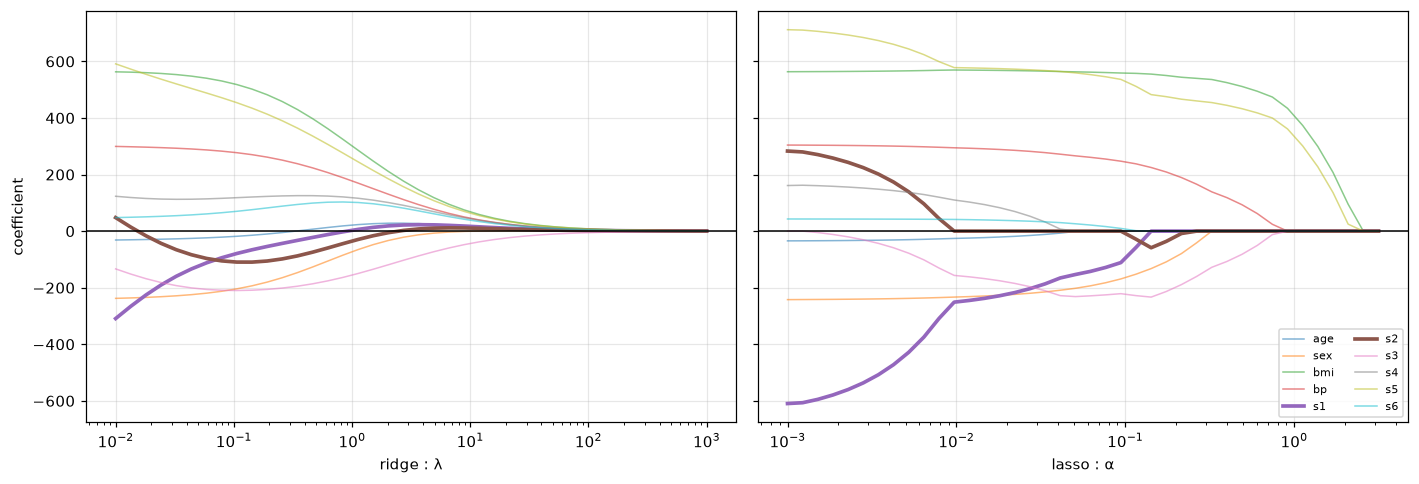

coefficients exactement nuls ; ridge : 0, lasso : 130 sur 400

lasso α = 0.05  s1 (cholestérol total)   -154.0, s2 (LDL)     -0.0
lasso α = 0.1   s1 (cholestérol total)   -105.7, s2 (LDL)     -0.0
lasso α = 0.2   s1 (cholestérol total)     -0.0, s2 (LDL)    -19.0
lasso α = 0.3   s1 (cholestérol total)     -0.0, s2 (LDL)     -0.0


In [6]:
ridge_path = np.array([Ridge(alpha=a).fit(X_train, y_train).coef_
                       for a in np.logspace(-2, 3, 40)])
lasso_path = np.array([Lasso(alpha=a, max_iter=100000).fit(X_train, y_train).coef_
                       for a in np.logspace(-3, 0.5, 40)])

assert lasso_path.shape == (40, 10)
assert (ridge_path == 0).sum() == 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for j, name in enumerate(feature_names):
    style = dict(lw=2.4) if name in ("s1", "s2") else dict(lw=1, alpha=0.55)
    axes[0].plot(np.logspace(-2, 3, 40), ridge_path[:, j], label=name, **style)
    axes[1].plot(np.logspace(-3, 0.5, 40), lasso_path[:, j], label=name, **style)
for ax, title in zip(axes, ["ridge : λ", "lasso : α"]):
    ax.set_xscale("log")
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel(title)
axes[0].set_ylabel("coefficient")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

print(f"coefficients exactement nuls ; ridge : {(ridge_path == 0).sum()}, "
      f"lasso : {(lasso_path == 0).sum()} sur {lasso_path.size}")
print()
for alpha in (0.05, 0.1, 0.2, 0.3):
    coefficients = Lasso(alpha=alpha, max_iter=100000).fit(X_train, y_train).coef_
    print(f"lasso α = {alpha:<5} s1 (cholestérol total) {coefficients[4]:8.1f}, "
          f"s2 (LDL) {coefficients[5]:8.1f}")

Le lasso garde `s1` et annule `s2` à $\alpha = 0{,}05$ et $0{,}1$, puis fait exactement l'inverse à
$\alpha = 0{,}2$. Un zéro du lasso ne dit donc pas « cette mesure n'a pas d'effet » ; il dit « cette
colonne n'a pas été retenue, à ce réglage ». Entre ces lignes, seul $\alpha$ a changé.

Le compte des zéros résume l'opposition : aucun côté ridge, 130 sur 400 côté lasso. Au clinicien qui
veut comprendre, le ridge garde les deux mesures et répond qu'elles portent le même signal ; au
laboratoire qui veut réduire ses coûts, les zéros du lasso sont exactement la réponse cherchée.